<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_06_abTEM_STEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  abTEM STEM, PRISM, and 4DSTEM simulation tutorial: GaAs [110]

This notebook shows:
- how to run STEM simulations in abTEM
- how to use the PRISM algorithm to speed up STEM simulations
- how to run a 4DSTEM simulations

We will use **Gallium Arsenide (GaAs)** oriented along the **[110]** zone axis as our sample.

In [47]:
# Install abTEM, which includes ASE and many other packages
!pip install abtem > /dev/null 2>&1
# !pip install git+https://github.com/abtem/abtem.git@master > /dev/null 2>&1

In [48]:
import sys
import typing

# --- Patch for Python < 3.11 ---
if sys.version_info < (3, 11):
    try:
        from typing_extensions import Self
        if not hasattr(typing, "Self"):
            typing.Self = Self
    except ImportError:
        print("Warning: 'typing_extensions' library not found. Please install it.")
# -------------------------------

import numpy as np
import matplotlib.pyplot as plt
import abtem
import ase
from ase.visualize import view

## Build atomic model - GaAs [110]

STEM simulations in general take a LOT longer than TEM simulations because each probe position requires a full multislice simulation (or at least a separate calculation).

Here, we will create a supercell of **GaAs [110]** that is large enough to encompass the probe and provide a reasonable Field of View (FOV).
We will build the unit cell from Kirkland's Table 7.1 coordinates and tile it to create a slab of approximately 24 x 22 x 40 Å.

Structure shape: [23.9849206  22.6132     39.97486766]


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Beam view'}, xlabel='x [Å]', ylabel='y [Å]'>)

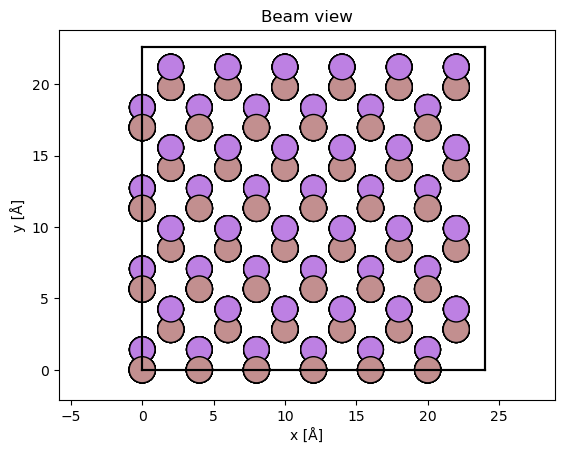

In [49]:
# Create atomic structure manually based on Kirkland Table 7.1
# Zincblende GaAs
a_gaas = 5.6533 

# Rectangular cell dimensions for [110] projection
# X = a/sqrt(2), Y = a, Z = a/sqrt(2)
a0 = a_gaas / np.sqrt(2) 
b0 = a_gaas              
c0 = a_gaas / np.sqrt(2) 

positions = [
    (0, 0, 0),                  # Ga
    (0.5 * a0, 0.75 * b0, 0),   # As
    (0, 0.25 * b0, c0/2),       # As
    (0.5 * a0, 0.5 * b0, c0/2)  # Ga
]
symbols = ['Ga', 'As', 'As', 'Ga']

base_atoms = ase.Atoms(symbols, positions=positions, cell=[a0, b0, c0], pbc=True)

# Create a supercell for STEM
# 6x4x10 tiles => ~24 x 22 x 40 Angstroms
atoms = base_atoms * (6, 4, 10)

print(f"Structure shape: {atoms.cell.lengths()}")

# Plot the resulting structure
abtem.show_atoms(
    atoms,
    title="Beam view",
    merge = False,
)

We can see the columns of Ga and As atoms. The rectangular unit cell is evident.

Next, create the projected potential using `abtem.FrozenPhonons()` and `abtem.Potential()`.
We will use thermal displacements appropriate for GaAs (~0.08 Å).

In [50]:
frozen_phonons = abtem.FrozenPhonons(
    atoms,
    num_configs=8,
    sigmas={'Ga': 0.08, 'As': 0.08},
    seed = 1,
)

# Use slice thickness matching the unit cell c0 (~2.0 or 4.0 A)
# c0 is ~4.0 A (2 atomic layers). We can define slices of 2.0 A or 4.0 A.
# Let's use 2.0 A to capture the layers separately if desired, or 4.0 A.
# Using 2.0 A is safer for multislice accuracy.
potential = abtem.Potential(
    frozen_phonons,
    sampling = 0.1, # 0.1 Angstrom sampling
    slice_thickness = 2.0, 
    # gpts = (80,96),
)

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

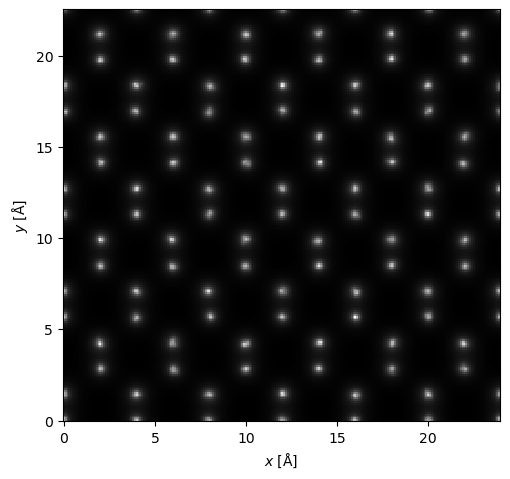

In [51]:
# plot the projected potential
potential.build().project().show(
    cmap='gray'
);

In [52]:
potential.build().array.shape

(8, 20, 240, 227)

## STEM probe wavefunctions

We will define our probe using
```
abtem.Probe()
```

We will do some plotting of the 2D image and 1D line traces to better understand the probe. We can access this wavefunction using
```
probe_wavefunction = probe.build().array
```

The most important parameters are energy and semiangle_cutoff. Let's use 80 kV and 25 mrads respectively.

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

RMS size = 0.304 Å


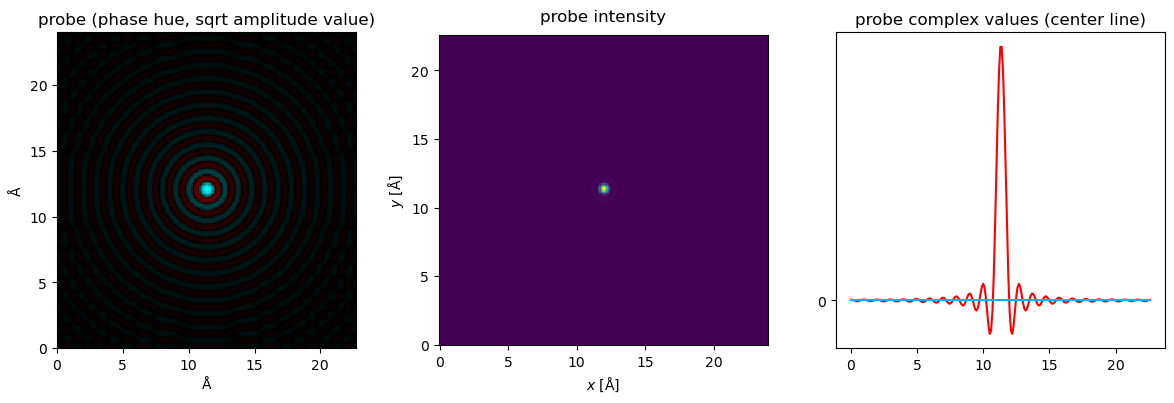

In [53]:
import numpy as np
import matplotlib.colors as mcolors

if not hasattr(np, "product"):
    np.product = np.prod

semiangle_cutoff = 25 # mrad

probe = abtem.Probe(
    energy=200e3, # 200 kV
    semiangle_cutoff=semiangle_cutoff,
    defocus=0,
)
probe.grid.match(potential)

wave = probe.build()
arr = np.asarray(wave.array)

sampling = float(probe.sampling[0])
nx, ny = arr.shape[1], arr.shape[0]
extent = (0, nx * sampling, 0, ny * sampling)

amp = np.abs(arr)
phase = np.angle(arr)
v = amp / (amp.max() if amp.max() != 0 else 1.0)
v **= 0.5
h = (phase + np.pi) / (2 * np.pi)
hsv = np.stack([h, np.ones_like(h), v], axis=-1)
rgb = mcolors.hsv_to_rgb(hsv)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(rgb, origin="lower", extent=extent, interpolation="nearest")
ax[0].set_title("probe (phase hue, sqrt amplitude value)")
ax[0].set_xlabel("Å")
ax[0].set_ylabel("Å")

probe_intensity = wave.intensity()
probe_intensity.show(ax=ax[1], title="probe intensity")

x_ind = arr.shape[0] // 2
x = np.arange(arr.shape[1]) * sampling
y = arr[x_ind, :]

ax[2].plot(x, np.real(y), color="r")
ax[2].plot(x, np.imag(y), color=(0, 0.7, 1))
ax[2].set_title("probe complex values (center line)")
ax[2].set_yticks([0])

y_int = np.abs(y) ** 2
x_mean = np.sum(x * y_int) / np.sum(y_int)
x_rms = np.sqrt(np.sum((x - x_mean) ** 2 * y_int) / np.sum(y_int))
x_rms_val = float(np.asarray(x_rms).item())

print(f"RMS size = {x_rms_val:.3f} Å")

fig.tight_layout()

# STEM probe scan field of view

One of the key differences between TEM and STEM experiments is that in STEM, we change the initial condition of the electron wavefunction many times and repeat the experiment (i.e. we scan the beam over the sample surface).

In abtem, we can define a grid of scan positions using
```
abtem.GridScan()
```

We will need to specify the start and end corners of our scan box, as well  as the sampling (keep in mind this is NOT the wavefunction sampling, this is sampling of the STEM probes). We can access some useful values here:
```
potential.extent
probe.ctf.nyquist_sampling
```

We can also overlay our scan box over the atomic potentials to make sure we're scanning the correct field of view.

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

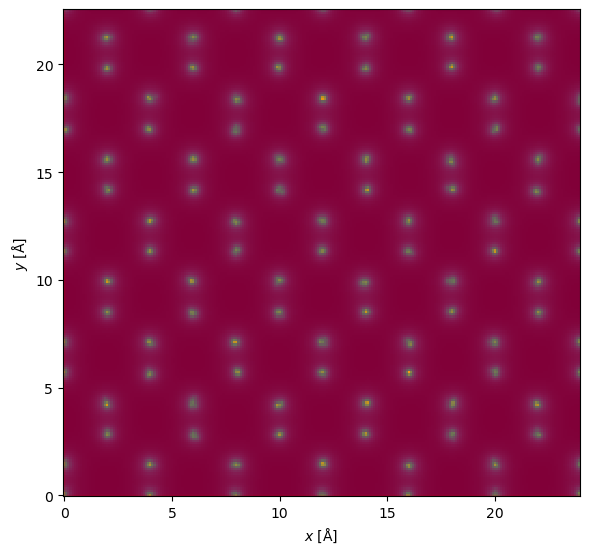

In [54]:
sampling = probe.aperture.nyquist_sampling

gridscan = abtem.GridScan(
    start=(0, 0),
    end=potential.extent,
    sampling=sampling,
    potential=potential,
)

proj = potential.project()

fig, ax = plt.subplots(figsize=(6, 6))
proj.show(ax=ax)
ax0 = ax

gridscan.add_to_plot(ax0)
fig.tight_layout()


## STEM Detector

Say we want to simulate a few different kinds of bright field and dark field detectors. These detectors are all circular or annualar.

We could simulate them all at the same time, but we would still need to define them ahead of time. If we use the FlexibleAnnularDetector() class, we can store the data as a function of the electron scattering angle. This will allow us to decide on the inner and outer angles after the simulation, i.e. with a lot more flexibility.

In [ ]:
%%time

flexible_detector = abtem.FlexibleAnnularDetector()

flexible_measurement = probe.scan(
    potential,
    scan=gridscan,
    detectors=flexible_detector,
).compute()


tasks:   0%|          | 0/557 [00:00<?, ?it/s]

In [ ]:
flexible_measurement.array.shape

(96, 91, 83, 1)

To specify a radial detector range, we can use this method
```
flexible_measurement.integrate()
```

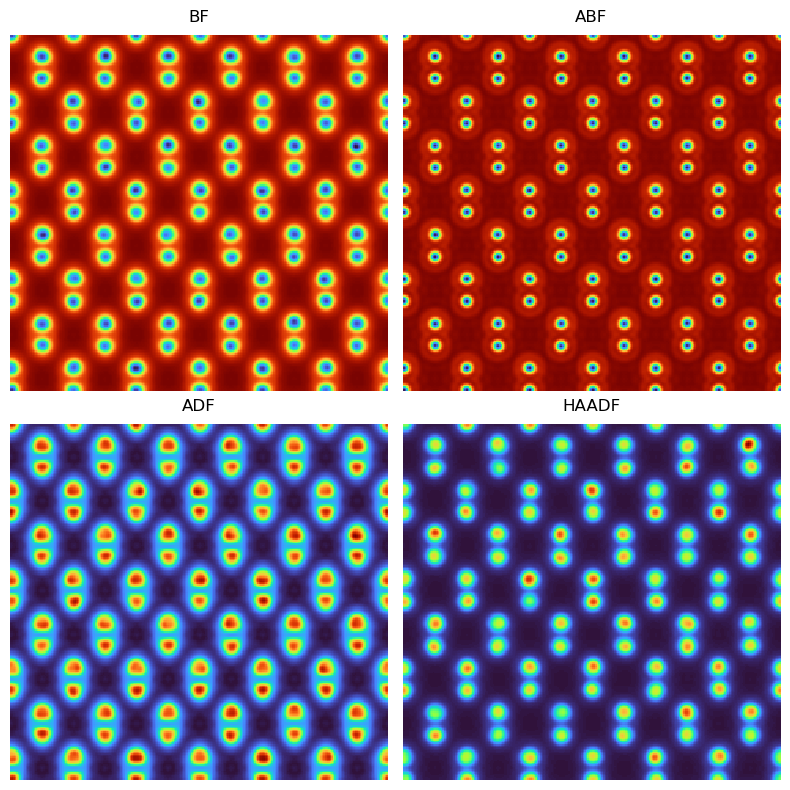

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(8,8))

meas_bf = flexible_measurement.integrate_radial(0, semiangle_cutoff)
meas_abf = flexible_measurement.integrate_radial(semiangle_cutoff * 0.5, semiangle_cutoff)
meas_adf = flexible_measurement.integrate_radial(semiangle_cutoff + 0.5, semiangle_cutoff + 5.0)
meas_haadf = flexible_measurement.integrate_radial(semiangle_cutoff * 3, flexible_measurement.outer_angle)

samp_output = 0.1
cmap = "turbo"

meas_bf.interpolate(samp_output).show(ax=ax[0, 0], cmap=cmap, title="BF")
meas_abf.interpolate(samp_output).show(ax=ax[0, 1], cmap=cmap, title="ABF")
meas_adf.interpolate(samp_output).show(ax=ax[1, 0], cmap=cmap, title="ADF")
meas_haadf.interpolate(samp_output).show(ax=ax[1, 1], cmap=cmap, title="HAADF")

for a in ax.ravel():
    a.axis("off")

fig.tight_layout()


# Noisy measurements

For this simulation of a 2D material, all 4 detectors seem to produce similar contrast.  But is this really true?

To properly evaluate the imaging quality, we need to use a realistic electron fluence (dose). Electron fluence is typically specified in units of electrons / Angstrom^2. If we manually compute the output images, we need to make sure to convert to units of "electrons per probe."




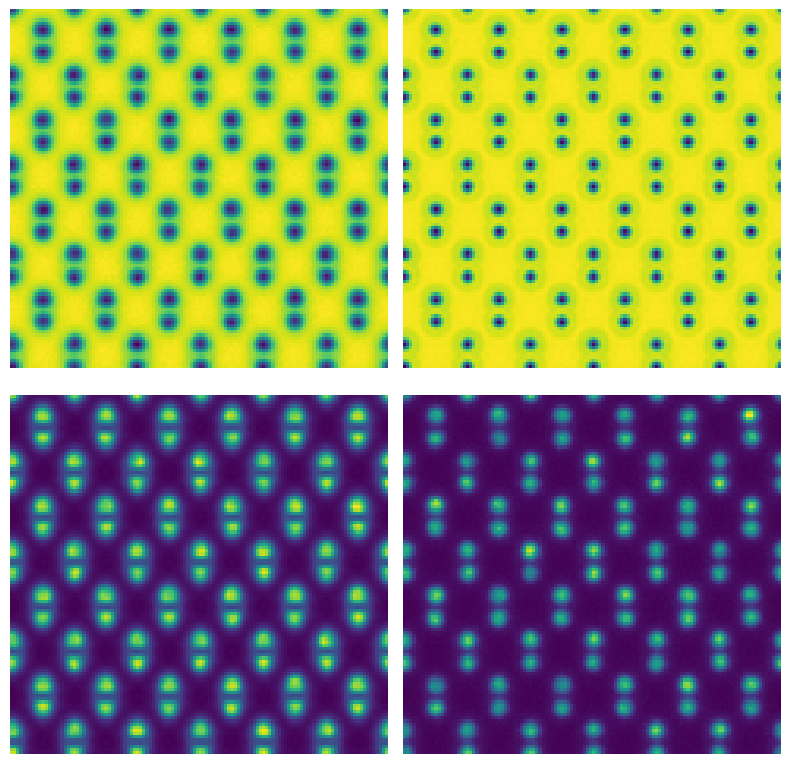

In [ ]:
# Calculate the noisy images and plot them
dose_per_A2 = 1e7
samp_output = 0.2
dose_per_probe_position = dose_per_A2 * samp_output**2

im_bf = np.random.poisson( dose_per_probe_position * \
    meas_bf.interpolate(samp_output).array)
im_abf = np.random.poisson( dose_per_probe_position * \
    meas_abf.interpolate(samp_output).array)
im_adf = np.random.poisson( dose_per_probe_position * \
    meas_adf.interpolate(samp_output).array)
im_haadf = np.random.poisson( dose_per_probe_position * \
    meas_haadf.interpolate(samp_output).array)


fig,ax = plt.subplots(2,2,figsize = (8,8))
ax[0,0].imshow(np.rot90(im_bf,1))
ax[0,1].imshow(np.rot90(im_abf))
ax[1,0].imshow(np.rot90(im_adf))
ax[1,1].imshow(np.rot90(im_haadf))

ax[0,0].axis('off');
ax[0,1].axis('off');
ax[1,0].axis('off');
ax[1,1].axis('off');
fig.tight_layout()

Which imaging mode is the most efficient?  

Which is the least efficient?

Why do you think these images produce such vastly different amounts of contrast?

## PRISM

The above simulations took a little while to compute. This is because we are simulating an entirely new multislice simulation for each STEM probe position.  Even if we simulate at Nyquist frequency, this is a lot of simulations!

However, when we are working at atomic resolution, most of the probe wavefunction intensities are ~0. So one way to speed up the simulation is to crop around the probe as propagate.  This leads to an f**2 speedup, for a cropping factor "f" applied in the x and y directions. However, we can do even better by using the PRISM algorithm. PRISM works by decomposing the multislice simulations into a series of plane wave simulations, and then rather than only cropping the output probes, we also apply Fourier interpolation.

The full algorithm is beyond of the scope of this workshop, but you can find more information here if you are interested:
- [PRISM algorithm paper](https://doi.org/10.1186/s40679-017-0046-1)
- [Prismatic simulation paper](https://doi.org/10.1186/s40679-017-0048-z)
- [abTEM guide to PRISM](https://abtem.readthedocs.io/en/latest/user_guide/tutorials/prism.html)

For now, we are going to use PRISM to compute the same STEM simulations as above, and estimate the speed up / loss of accuracy if any.

Note - in this version of abTEM, using the scattering matrix is a bit tedious and so we have included all of the code you need below. For a look at the modern abTEM implementation of PRISM, see the link above.

In [ ]:
%%time

S = abtem.SMatrix(
    potential=potential,
    interpolation=2,
    energy=200e3, # Match the probe energy
    semiangle_cutoff=semiangle_cutoff,
)

# S_array = S.build() # Optional build

# Run PRISM reduction for your scan with the flexible detector (no need to pass potential again)
flexible_measurement_prism = S.scan(
    scan=gridscan,
    detectors=flexible_detector,
).compute()

# If you want to apply defocus / other aberrations, pass a CTF to scan (PRISM tutorial pattern)
ctf0 = abtem.CTF(energy=200e3, defocus=0, semiangle_cutoff=semiangle_cutoff)

flexible_measurement_prism_defocus0 = S.scan(
    scan=gridscan,
    detectors=flexible_detector,
    ctf=ctf0,
).compute()

/Users/robertoreis/anaconda3/envs/matsci465/lib/python3.10/site-packages/abtem/prism/s_matrix.py:1480: UserWarning: The interpolation factor does not exactly divide 'gpts', normalizationmay not be exactly preserved.
  warnings.warn(


tasks:   0%|          | 0/88 [00:00<?, ?it/s]

/Users/robertoreis/anaconda3/envs/matsci465/lib/python3.10/site-packages/abtem/prism/s_matrix.py:1480: UserWarning: The interpolation factor does not exactly divide 'gpts', normalizationmay not be exactly preserved.
  warnings.warn(


tasks:   0%|          | 0/88 [00:00<?, ?it/s]

/Users/robertoreis/anaconda3/envs/matsci465/lib/python3.10/site-packages/abtem/prism/s_matrix.py:1480: UserWarning: The interpolation factor does not exactly divide 'gpts', normalizationmay not be exactly preserved.
  warnings.warn(


CPU times: user 11min 19s, sys: 29.5 s, total: 11min 48s
Wall time: 1min 28s


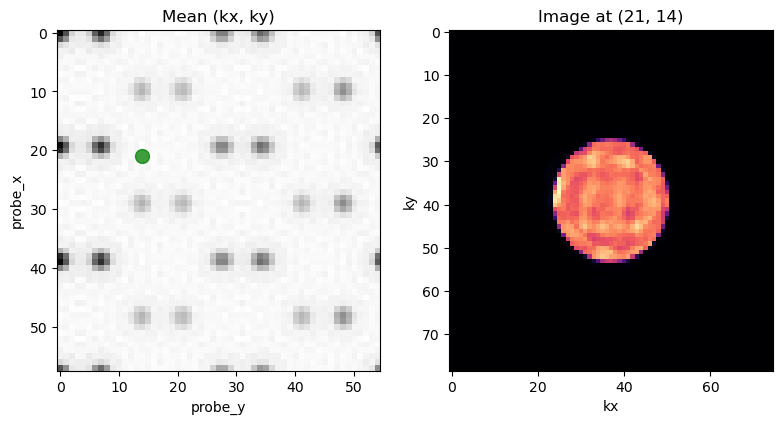

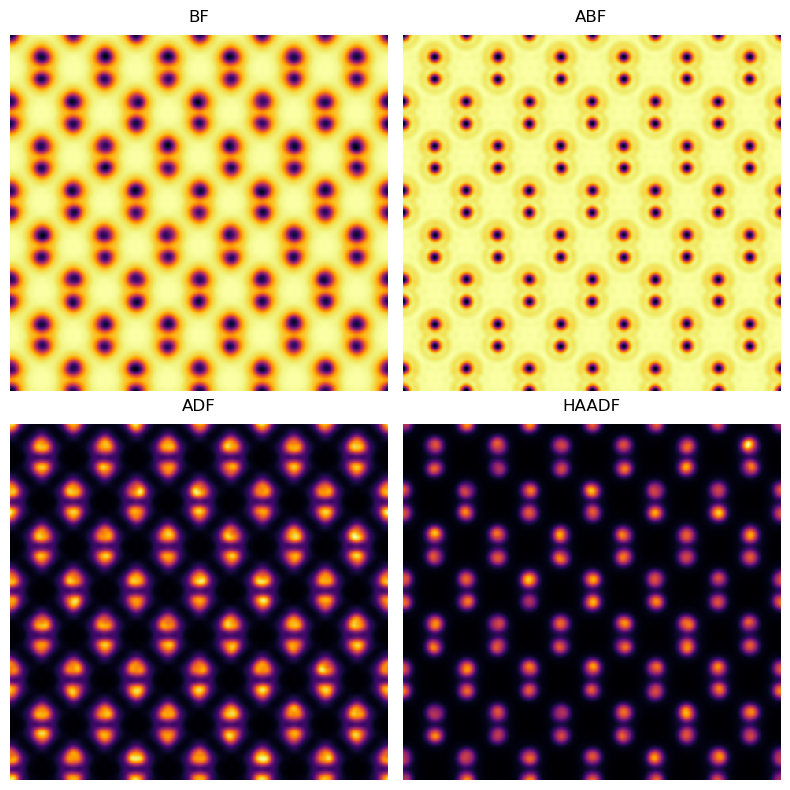

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

meas_bf = flexible_measurement_prism_defocus0.integrate_radial(0, semiangle_cutoff)
meas_abf = flexible_measurement_prism_defocus0.integrate_radial(semiangle_cutoff * 0.5, semiangle_cutoff)
meas_adf = flexible_measurement_prism_defocus0.integrate_radial(semiangle_cutoff + 0.5, semiangle_cutoff + 5.0)
meas_haadf = flexible_measurement_prism_defocus0.integrate_radial(
    semiangle_cutoff * 3, flexible_measurement_prism_defocus0.outer_angle
)

samp_output = 0.05
cmap = "inferno"

meas_bf.interpolate(samp_output).show(ax=ax[0, 0], cmap=cmap, title="BF")
meas_abf.interpolate(samp_output).show(ax=ax[0, 1], cmap=cmap, title="ABF")
meas_adf.interpolate(samp_output).show(ax=ax[1, 0], cmap=cmap, title="ADF")
meas_haadf.interpolate(samp_output).show(ax=ax[1, 1], cmap=cmap, title="HAADF")

for a in ax.ravel():
    a.axis("off")

fig.tight_layout()


## 4DSTEM simulations

So far, we have only simulated conventional STEM detectors. abTEM can also simulate more complex detectors such as segmented detectors. However, the most flexible detector of them all is to save the full image of the diffracted STEM probe at each probe position. This data is known as Four-Dimensional STEM (4DSTEM).

From a simulation perspective, 4DSTEM simulations simply require saving the full 4D output (2D probe positions x 2D diffraction patterns).
However, the dataset size can be large.
- 2D: $(4)(500^2)$ = 1 MB
- 4D: $(4)(500^2)(100^2)$ = 10 GB

We will simulate a small 4DSTEM dataset for our **GaAs [110]** structure to keep memory usage low.
We will use a relatively small field of view (~1 x 1 nm).

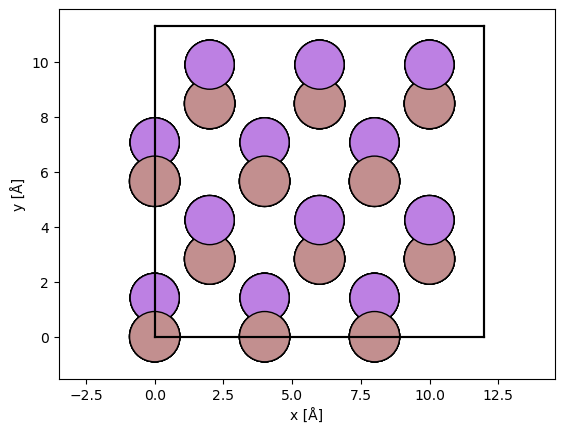

In [ ]:
# Create GaAs [110] structure for 4DSTEM (keeping it small)
a_gaas = 5.6533 
a0 = a_gaas / np.sqrt(2) 
b0 = a_gaas              
c0 = a_gaas / np.sqrt(2) 

positions = [
    (0, 0, 0),                  # Ga
    (0.5 * a0, 0.75 * b0, 0),   # As
    (0, 0.25 * b0, c0/2),       # As
    (0.5 * a0, 0.5 * b0, c0/2)  # Ga
]
symbols = ['Ga', 'As', 'As', 'Ga']

base_atoms = ase.Atoms(symbols, positions=positions, cell=[a0, b0, c0], pbc=True)

# 2x2 tiling => ~8 x 11 Angstroms (approx 1x1 nm)
atoms_4D = base_atoms * (3, 2, 6) # ~24 A thick

abtem.show_atoms(
    atoms_4D,
    plane='xy',
    merge=False,
);

Now let's choose the zone axis - is there a projection direction where we don't have and columns of multiple atomic species?

In [ ]:
atoms_4D.cell

Cell([11.992460298245726, 11.3066, 23.984920596491452])

Initialize the simulation using these parameters:
- energy = 200 kV
- semiangle = 30 mrads
- defocus = 0 A
- sampling = 0.1 A

We aim for a thickness of ~2-3 nm (here we used 6 unit cells ~ 2.4 nm).

In [ ]:
# initialize the simulation objects: probe, potential, gridscan

probe = abtem.Probe(
    energy=200e3, # 200 kV
    semiangle_cutoff=30,
    defocus=0)

potential = abtem.Potential(
    atoms_4D, # Already tiled (2,2,6)
    sampling = 0.16,
    slice_thickness = 2.0,
)
probe.grid.match(potential)

gridscan = abtem.GridScan(
    start = [0,0],
    end = potential.extent,
    sampling=probe.ctf.nyquist_sampling * 1.0)

In [ ]:
# Define a pixelated detector, with a maximum scattering angle of 80 mrads
pixelated_detector = abtem.PixelatedDetector(max_angle = 80)

In [ ]:
%%time

pixelated_measurement = probe.scan(
    potential,
    scan=gridscan,
    detectors=pixelated_detector,
).compute()


tasks:   0%|          | 0/7 [00:00<?, ?it/s]

CPU times: user 10.8 s, sys: 579 ms, total: 11.4 s
Wall time: 10.5 s


Keep in mind this is a relatively fast 4DSTEM simulation!  Real world simulations can take many many hours to compute. This is yet another reason why the PRISM algorithm may be helpful.

In fact, if we add inelastic scattering (double channeling) to our simulations, simulation times using the naive algorithm may be measured in YEARS. PRISM is especially useful for these cases, for an example see this paper:
- [Linear-scaling algorithm for rapid computation of inelastic transitions in the presence of multiple electron scattering
](http://dx.doi.org/10.1103/PhysRevResearch.1.033186)


In [ ]:
# Let's examine the dataset shape - why does it have this shape?
pixelated_measurement.shape

(58, 55, 79, 75)

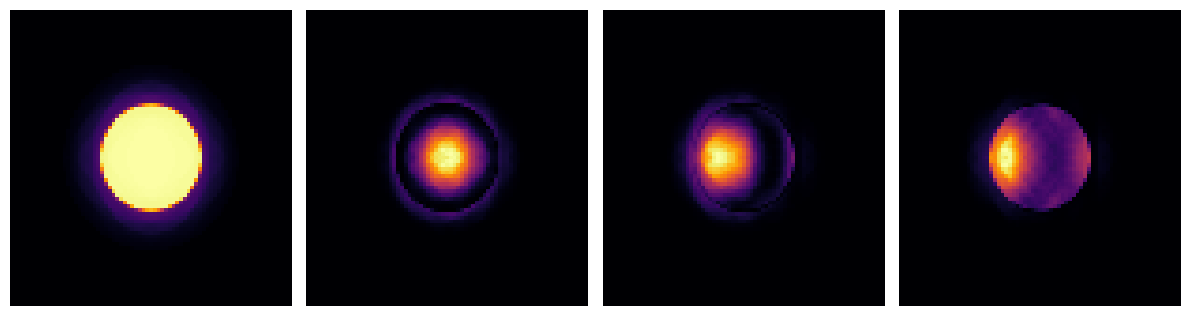

In [ ]:
# Now let's plot some of the diffraction patterns

fig,ax = plt.subplots(1,4,figsize=(12,4))
ax[0].imshow(
    np.mean(pixelated_measurement.array, axis = (0,1))**0.5,
    cmap = 'inferno',
)
ax[1].imshow(
    pixelated_measurement.array[0,0],
    cmap = 'inferno',
)
ax[2].imshow(
    pixelated_measurement.array[0,1],
    cmap = 'inferno',
)
ax[3].imshow(
    pixelated_measurement.array[0,2],
    cmap = 'inferno',
)

ax[0].axis('off');
ax[1].axis('off');
ax[2].axis('off');
ax[3].axis('off');
fig.tight_layout()

## 4D Data Browser - matplotlib

It will take us a very long time to example these diffraction patterns one at a time!  Instead, let's use a widget to scrub through the data.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
%matplotlib inline

In [ ]:
# data
data = pixelated_measurement.array

# Initial probe positions
init_x, init_y = data.shape[0]//2, data.shape[1]//2

# Create widgets
slider_x = widgets.IntSlider(value=init_x, min=0, max=data.shape[0]-1, description='probe_x')
slider_y = widgets.IntSlider(value=init_y, min=0, max=data.shape[1]-1, description='probe_y')

# Set up figure
with plt.ioff():
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(8, 4))
    plt.tight_layout()

# Precompute and plot mean along kx, ky (left panel)
mean_image = data.mean(axis=(2, 3))
ax_left.imshow(mean_image, cmap='gray')
scatter_marker, = ax_left.plot(
    [init_y], [init_x], color='green', marker='o',
    linestyle='None', markersize = 10, alpha = 0.75)
ax_left.set_title("Mean (kx, ky)")
ax_left.set_xlabel('probe_y')
ax_left.set_ylabel('probe_x')

# Enable dragging of the marker
dragging = {'active': False}

def on_press(event):
    if event.inaxes != ax_left:
        return
    contains, _ = scatter_marker.contains(event)
    if contains:
        dragging['active'] = True

def on_release(event):
    dragging['active'] = False

def on_motion(event):
    if dragging['active'] and event.inaxes == ax_left:
        new_x = int(round(event.xdata))
        new_y = int(round(event.ydata))
        new_x = np.clip(new_x, 0, data.shape[1] - 1)
        new_y = np.clip(new_y, 0, data.shape[0] - 1)
        slider_x.value = new_y
        slider_y.value = new_x

# Add arrow key interaction
def on_key(event):
    x, y = slider_x.value, slider_y.value
    if event.key == 'up':
        slider_x.value = max(0, x - 1)
    elif event.key == 'down':
        slider_x.value = min(data.shape[0] - 1, x + 1)
    elif event.key == 'left':
        slider_y.value = max(0, y - 1)
    elif event.key == 'right':
        slider_y.value = min(data.shape[1] - 1, y + 1)

fig.canvas.mpl_connect('button_press_event', on_press)
fig.canvas.mpl_connect('button_release_event', on_release)
fig.canvas.mpl_connect('motion_notify_event', on_motion)
fig.canvas.mpl_connect('key_press_event', on_key)

# Function to update plots based on sliders
def update_plot(probe_x, probe_y):
    scatter_marker.set_data([probe_y], [probe_x])

    ax_right.clear()
    specific_image = data[probe_x, probe_y]
    ax_right.imshow(specific_image, cmap='magma')
    ax_right.set_title(f"Image at ({probe_x}, {probe_y})")
    ax_right.set_xlabel('kx')
    ax_right.set_ylabel('ky')

    fig.canvas.draw()
    display(fig)

# Interactive widget
ui = widgets.HBox([slider_x, slider_y])
out = widgets.interactive_output(update_plot, {'probe_x': slider_x, 'probe_y': slider_y})

# Display widgets and plot
display(ui, out)

Output()

## 4D Data Browser - plotly

It will take us a very long time to example these diffraction patterns one at a time!  Instead, let's use a widget to scrub through the data.


In [ ]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [ ]:
# from google.colab import output
# output.enable_custom_widget_manager()

In [ ]:

# Initial probe positions
init_x, init_y = data.shape[0] // 2, data.shape[1] // 2

# Mean image along kx, ky
mean_image = data.mean(axis=(2, 3))

# Create interactive Plotly figures
fig_mean = go.FigureWidget(
    data=[go.Heatmap(z=mean_image, colorscale='gray'),
          go.Scatter(x=[init_y], y=[init_x], mode='markers', marker=dict(color='green', size=10))],
    layout=go.Layout(height=400, width=400, title='Mean (kx, ky)')
)

fig_specific = go.FigureWidget(
    data=[go.Heatmap(z=data[init_x, init_y], colorscale='magma')],
    layout=go.Layout(height=400, width=400, title=f'Image at ({init_x}, {init_y})')
)

# Widgets
slider_x = widgets.IntSlider(value=init_x, min=0, max=data.shape[0]-1, description='probe_x')
slider_y = widgets.IntSlider(value=init_y, min=0, max=data.shape[1]-1, description='probe_y')

# Update function
def update(change):
    probe_x, probe_y = slider_x.value, slider_y.value
    with fig_mean.batch_update():
        fig_mean.data[1].x = [probe_y]
        fig_mean.data[1].y = [probe_x]
    with fig_specific.batch_update():
        fig_specific.data[0].z = data[probe_x, probe_y]
        fig_specific.layout.title = f'Image at ({probe_x}, {probe_y})'

# Keyboard interaction
def on_key(event):
    if event['key'] == 'ArrowUp':
        slider_x.value = max(0, slider_x.value - 1)
    elif event['key'] == 'ArrowDown':
        slider_x.value = min(data.shape[0] - 1, slider_x.value + 1)
    elif event['key'] == 'ArrowLeft':
        slider_y.value = max(0, slider_y.value - 1)
    elif event['key'] == 'ArrowRight':
        slider_y.value = min(data.shape[1] - 1, slider_y.value + 1)

# Connect sliders to update function
slider_x.observe(update, names='value')
slider_y.observe(update, names='value')

# Attach keyboard listener
fig_mean.layout.on_change(on_key, 'uirevision')

# Display widgets and figures side-by-side
ui = widgets.HBox([slider_x, slider_y])
figs = widgets.HBox([fig_mean, fig_specific])

display(ui, figs)

    'data': [{'colorscale': [[0.0, 'rgb(0, 0, 0)'], [0.09090909090909091, 'rgb(1…